[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Optimizer077/jev-learning-course/blob/main/notebooks/09_related_models_lab.ipynb)

# 9 · Related models: compare three ways to route a message

**Path:** Optional comparison lab  
**Before you start:** Lesson 07; basic arrays; lexical matching is explained here

[Course home](../README.md) · [Course outline](../docs/COURSE.md) · [Setup help](../docs/SETUP.md) · [Glossary](../docs/GLOSSARY.md)

## The idea before the code

Different mechanisms can return the same label while using different information. Compare their behavior on fixed examples, then inspect the cases where the representation fails.

**Your first pass:** Read the mechanism table and the comparison counts first. Return to the implementation when ready.

### Words you need for this lesson

| Word | Everyday meaning |
|---|---|
| **Prototype** | A representative vector built from examples in a class. |
| **Cosine similarity** | How closely the directions of two numerical vectors align. |
| **Abstention** | Choosing review instead of an automatic answer. |

## Goal
See why a typed decision interface, a text representation, and a decision rule are different parts
of a system. Compare three small implementations on **the same twelve fictional test messages**.

We execute keyword rules, lexical prototype matching, and the learned NumPy classifier from lesson 07.
The table below places those examples beside broader model families. It describes mechanisms;
the experiment measures only our local examples.

| Approach | How it reaches an answer | What the output means | Implemented here? |
|---|---|---|---|
| Keyword rules | Match words against explicit conditions | A rule-selected label, or review | Yes |
| Lexical prototype matching | Compare weighted word vectors with class examples | A similarity score and a selected label | Yes |
| Learned linear classifier | Learn feature weights from labeled examples | A label and softmax probabilities; calibration still needs evaluation | Yes |
| Contextual encoder plus classifier | Build context-sensitive representations, then predict a task label | A learned task output | No; see the linked BERT paper |
| Generative language model | Produce output tokens conditioned on the input | Generated text or a requested structured answer | No |
| Jev / System One | Evaluate supplied state against typed questions | Documented Choice, Score, and Noul results | No live call in this lab |

For Jev's contract, use [the official System One page](https://docs.typesafe.ai/concepts/system-one).
For contextual language representations, see [BERT](https://aclanthology.org/N19-1423/).
A local linear classifier helps explain a classifier head, but lacks BERT's language representation.

## Setup
CPU-only NumPy experiments. No downloaded model, extra dependency, or API account is required.
This notebook runs independently of earlier notebooks.

In [1]:
# Find the included teaching helpers from the course folder.
from pathlib import Path
import sys
REQUIRED_FILES = ("src/lab_core.py", "src/tutorial_utils.py", "data/tickets.json",
                  "assets/decision-flow.png", "assets/question-types.png",
                  "assets/calibration-counts.png", "assets/data-splits.png", "assets/word-order.png")
COURSE_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                    if all((p / name).is_file() for name in REQUIRED_FILES)), None)
# Colab opens a single notebook; fetch its companion code and fictional data.
if COURSE_ROOT is None:
    try:
        import google.colab
    except ImportError:
        pass
    else:
        import subprocess
        COURSE_ROOT = Path("/content/jev-learning-course")
        if COURSE_ROOT.exists() and not all((COURSE_ROOT / name).is_file() for name in REQUIRED_FILES):
            raise FileNotFoundError("The cached Colab course is incomplete. Start a fresh runtime and run all again.")
        if not COURSE_ROOT.exists():
            subprocess.run(["git", "clone", "--depth", "1",
                            "https://github.com/Optimizer077/jev-learning-course.git",
                            str(COURSE_ROOT)], check=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Extract the complete course and open it from its folder.")
if str(COURSE_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from tutorial_utils import setup, show_figure, table, BLUE, ORANGE, GREY
setup()

from lab_core import (LABELS, WORD_ORDER_PAIR, tokenise, vectorise, train_text_baseline, split_arrays, softmax)

## Steps
### 1. Hold the examples and task fixed
Fit the vocabulary and learned weights using the fixed training split. Build lexical prototypes
from training examples too. We report all methods on the same test split with the same reference labels.

The keyword dictionary below is hand-authored, then held fixed for this demonstration. Its design
is part of the authored teaching task, rather than an independently blinded experiment. No tuning
on test examples occurs inside this notebook. All results describe this tiny course dataset.

In [2]:
related_rows, related_vocab, related_weights, related_bias, _ = train_text_baseline()
related_training, related_X_train, related_y_train = split_arrays(related_rows, 'train', related_vocab)
related_test, related_X_test, related_y_test = split_arrays(related_rows, 'test', related_vocab)
print(f'Fit on {len(related_training)} training examples; compare on {len(related_test)} test examples.')
table(['Case', 'Reference primary queue', 'Message'],
      [[r['id'], r['label'], r['text']] for r in related_test[:4]])

Fit on 24 training examples; compare on 12 test examples.


Case,Reference primary queue,Message
test-037,billing,The payment receipt lists two charges.
test-038,billing,A refund is missing from my card statement.
test-039,billing,Please explain why the invoice price changed.
test-040,billing,My subscription was charged again after cancellation.


### 2. Make the rule explicit
Each queue has trigger words. If exactly one queue has the largest **positive** count, choose it.
If there are no matches or a tie, return `review`. This is a transparent rule with real limitations:
it can miss synonyms and ignore what a negation refers to.

These counts are counts, not probabilities. The rule has no learned confidence field.

In [3]:
related_keywords = {
    'billing': {'invoice', 'payment', 'refund', 'charge', 'charged', 'price', 'billing'},
    'technical': {'export', 'crash', 'crashes', 'broken', 'error', 'upload', 'bug', 'fails'},
    'account': {'password', 'login', 'account', 'access', 'email', 'signin'},
}

def route_by_keywords(text):
    words = set(tokenise(text))
    counts = {label: len(words & related_keywords[label]) for label in LABELS}
    largest = max(counts.values())
    winners = [label for label,count in counts.items() if count == largest]
    return winners[0] if largest > 0 and len(winners) == 1 else 'review'

table(['Message', 'Rule result'], [
    ['The export crashes.', route_by_keywords('The export crashes.')],
    ['Please explain quasar spectroscopy.', route_by_keywords('Please explain quasar spectroscopy.')],
    ['The payment failed, not the export.', route_by_keywords('The payment failed, not the export.')],
])

Message,Rule result
The export crashes.,technical
Please explain quasar spectroscopy.,review
"The payment failed, not the export.",review


### 3. Match lexical prototypes
Make one vector per message. A known word contributes 1 when present, otherwise 0. Give words that
appear in fewer **training documents** a larger inverse-document-frequency weight. Normalize each
vector to length 1, average the vectors within each class, then normalize those class averages.
The class averages are our **prototypes**.

For a new message, the dot product of two unit vectors gives their cosine similarity. Choose the
most similar prototype; review if every score is zero. This is lexical matching, so word order
still disappears. It is not a neural embedding model or retrieval-augmented generation system.

Our binary term-presence variant uses smoothed weights
$\operatorname{idf}(w)=1+\log[(1+N)/(1+\operatorname{df}(w))]$.
See [the primary feature-extraction documentation](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)
for TF–IDF conventions. The implementation below uses NumPy, not scikit-learn.

In [4]:
def normalise_rows(matrix):
    length = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.maximum(length, 1e-12)

related_document_frequency = related_X_train.sum(axis=0)
related_idf = 1 + np.log((1 + len(related_X_train)) / (1 + related_document_frequency))
related_training_vectors = normalise_rows(related_X_train * related_idf)
related_prototypes = normalise_rows(np.vstack([
    related_training_vectors[related_y_train == i].mean(axis=0) for i in range(len(LABELS))
]))

def lexical_scores(texts):
    vectors = normalise_rows(vectorise(texts, related_vocab) * related_idf)
    return vectors @ related_prototypes.T

def lexical_labels(scores):
    return [LABELS[row.argmax()] if row.max() > 1e-12 else 'review' for row in scores]

related_similarity = lexical_scores([r['text'] for r in related_test])
table(['Case', *[f'{label} similarity' for label in LABELS], 'Sum of similarities'],
      [[r['id'], *[f'{value:.3f}' for value in scores], f'{scores.sum():.3f}']
       for r,scores in zip(related_test[:4], related_similarity[:4])])

Case,billing similarity,technical similarity,account similarity,Sum of similarities
test-037,0.349,0.106,0.032,0.487
test-038,0.408,0.192,0.160,0.761
test-039,0.412,0.068,0.096,0.576
test-040,0.304,0.053,0.159,0.516


**Read the numbers carefully:** these similarities are not probabilities. They need not sum to 1.
Even if they happen to sum near 1 for one message, that does not establish a probability interpretation.
Normalizing arbitrary scores afterward would still require calibration evaluation.

The heatmap shows every held-out message against the three prototypes. The largest value in each
row picks a queue. A high lexical match can still represent the wrong meaning.

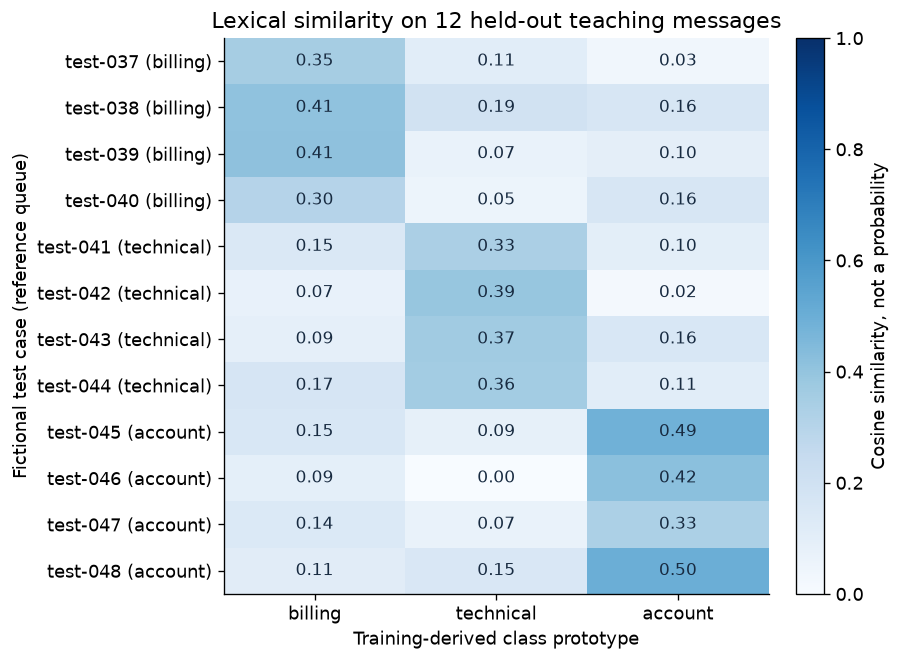

In [5]:
fig, ax = plt.subplots(figsize=(7.4, 5.4))
image = ax.imshow(related_similarity, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(LABELS)), LABELS)
ax.set_yticks(range(len(related_test)), [f"{r['id']} ({r['label']})" for r in related_test])
ax.set_xlabel('Training-derived class prototype')
ax.set_ylabel('Fictional test case (reference queue)')
ax.set_title('Lexical similarity on 12 held-out teaching messages')
for row in range(len(related_test)):
    for col in range(len(LABELS)):
        value = related_similarity[row,col]
        ax.text(col,row,f'{value:.2f}',ha='center',va='center',
                color='white' if value > .55 else '#182b41',fontsize=10)
fig.colorbar(image, ax=ax, label='Cosine similarity, not a probability')
show_figure('09_lexical_similarity')

### 4. Compare behavior on the same twelve cases
The learned linear model uses the same binary vocabulary but **learns weights** rather than
comparing class averages. We use its largest softmax probability for the label here, with no review
cutoff, so it automatically chooses a class for every case. This choice is explicit; the calibrated
review policy in lesson 07 is a separate experiment.

Report automatic coverage and the fraction correct **among automatic routes**, with both denominators.
For the count chart, every test case appears exactly once as correct, wrong, or reviewed.
There is no measured Jev, BERT, or generative-model result in this comparison.

Method,Automatic / all,Correct / automatic,Wrong / automatic,Reviewed / all
Keyword rules,10/12,10/10,0/10,2/12
Lexical prototypes,12/12,12/12,0/12,0/12
Learned linear,12/12,12/12,0/12,0/12


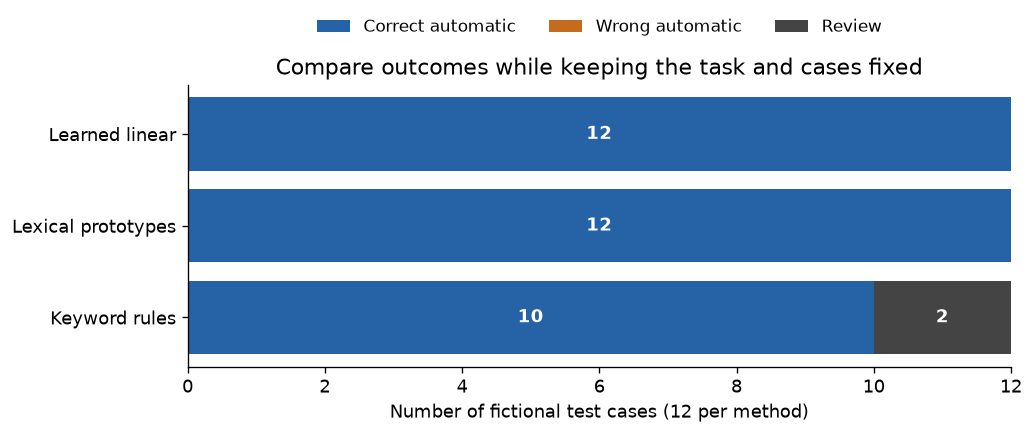

In [6]:
related_linear_p = softmax(related_X_test @ related_weights + related_bias)
related_predictions = {
    'Keyword rules': [route_by_keywords(r['text']) for r in related_test],
    'Lexical prototypes': lexical_labels(related_similarity),
    'Learned linear': [LABELS[i] for i in related_linear_p.argmax(axis=1)],
}
related_counts = []
for method,predictions in related_predictions.items():
    correct = sum(pred == r['label'] for pred,r in zip(predictions,related_test))
    review = sum(pred == 'review' for pred in predictions)
    automatic = len(predictions) - review
    wrong = automatic - correct
    related_counts.append((correct,wrong,review))
table(['Method', 'Automatic / all', 'Correct / automatic', 'Wrong / automatic', 'Reviewed / all'],
      [[method, f'{correct+wrong}/{len(related_test)}', f'{correct}/{correct+wrong}' if correct+wrong else 'n/a',
        f'{wrong}/{correct+wrong}' if correct+wrong else 'n/a', f'{review}/{len(related_test)}']
       for method,(correct,wrong,review) in zip(related_predictions,related_counts)])

fig, ax = plt.subplots(figsize=(8.5, 3.5))
left = np.zeros(len(related_predictions))
for column,(title,color) in enumerate([('Correct automatic',BLUE),('Wrong automatic',ORANGE),('Review',GREY)]):
    counts = np.array([row[column] for row in related_counts])
    ax.barh(list(related_predictions),counts,left=left,color=color,label=title)
    for row,count in enumerate(counts):
        if count: ax.text(left[row]+count/2,row,str(count),ha='center',va='center',color='white',fontweight='bold')
    left += counts
ax.set_xlim(0,len(related_test)); ax.set_xticks(range(0,len(related_test)+1,2))
ax.set_xlabel('Number of fictional test cases (12 per method)')
ax.set_title('Compare outcomes while keeping the task and cases fixed')
ax.legend(loc='lower center',bbox_to_anchor=(.5,1.12),ncol=3,frameon=False,fontsize=10)
show_figure('09_method_outcomes')

**Interpretation:** inspect the counts rather than declaring a winning model family. These methods
and data were designed for teaching; twelve easy cases cannot establish broad reliability. A method
that reviews more cases may make fewer automatic mistakes while leaving more work for a reviewer.
This comparison records routing behavior, not end-to-end review quality or service costs.

### 5. Find where the methods disagree
Read the complete per-case comparison, then inspect each disagreement with the original text.
Small changes in wording can matter more than the aggregate score.

In [7]:
table(['Case','Reference',*related_predictions], [
    [r['id'],r['label'],*[predictions[i] for predictions in related_predictions.values()]]
    for i,r in enumerate(related_test)
])
related_disagreements = [i for i in range(len(related_test))
                         if len({predictions[i] for predictions in related_predictions.values()}) > 1]
if related_disagreements:
    for i in related_disagreements:
        print(related_test[i]['id'] + ': ' + related_test[i]['text'])
else:
    print('The methods agree on these twelve cases. That does not establish broader equivalence.')

Case,Reference,Keyword rules,Lexical prototypes,Learned linear
test-037,billing,billing,billing,billing
test-038,billing,billing,billing,billing
test-039,billing,billing,billing,billing
test-040,billing,billing,billing,billing
test-041,technical,technical,technical,technical
test-042,technical,technical,technical,technical
test-043,technical,review,technical,technical
test-044,technical,review,technical,technical
test-045,account,account,account,account
test-046,account,account,account,account


test-043: The app crashes but login works.
test-044: The page freezes before I can download a report.


### 6. Construct a shared failure

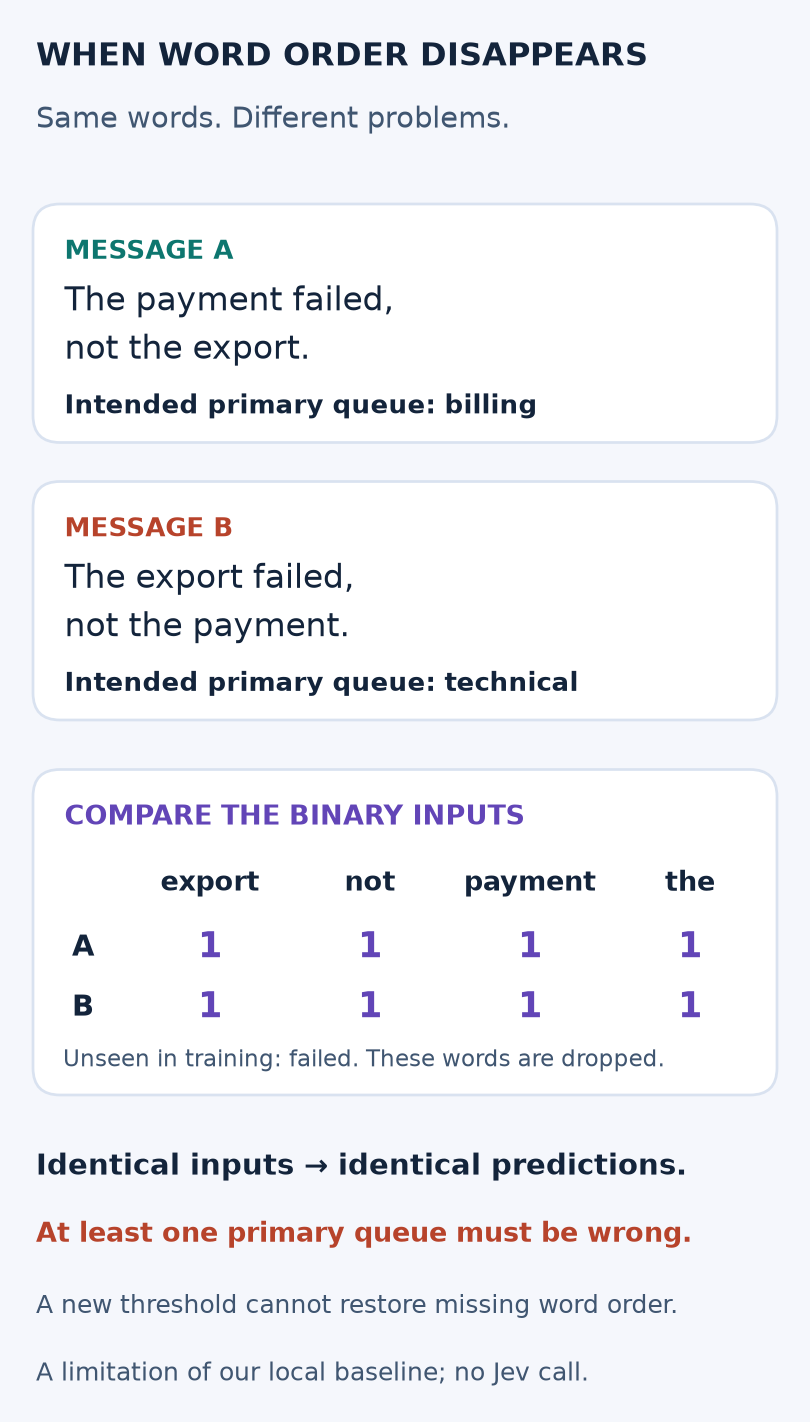

In [8]:
from tutorial_utils import show_diagram
show_diagram('word-order', 'Two different meanings produce the same binary features, so the vector-based methods cannot distinguish them.')

These two messages contain the same words, but “not” changes which failure is being denied.
Their intended primary queues are different. Both the prototype matcher and the learned classifier
receive identical word-presence vectors, so they cannot produce different answers for this pair.
The keyword rule also sees the same set of words, though it can send both to review.

In [9]:
related_pair = [message for message, _ in WORD_ORDER_PAIR]
related_pair_reference = [reference for _, reference in WORD_ORDER_PAIR]
related_pair_X = vectorise(related_pair,related_vocab)
related_pair_lexical = lexical_labels(lexical_scores(related_pair))
related_pair_linear = [LABELS[i] for i in softmax(related_pair_X @ related_weights + related_bias).argmax(axis=1)]
table(['Message','Reference','Keyword rule','Lexical prototype','Learned linear'],[
    [text,reference,route_by_keywords(text),prototype,linear]
    for text,reference,prototype,linear in zip(related_pair,related_pair_reference,related_pair_lexical,related_pair_linear)
])
assert np.array_equal(related_pair_X[0],related_pair_X[1])
print('Identical features: the two vector-based methods cannot distinguish this pair.')

Message,Reference,Keyword rule,Lexical prototype,Learned linear
"The payment failed, not the export.",billing,review,billing,billing
"The export failed, not the payment.",technical,review,billing,billing


Identical features: the two vector-based methods cannot distinguish this pair.


## Checks
The checks below verify accounting and the representation limitation. They deliberately make
no assertion that one approach should outperform another.

In [10]:
assert set(related_predictions) == {'Keyword rules','Lexical prototypes','Learned linear'}
assert all(len(predictions) == len(related_test) for predictions in related_predictions.values())
assert all(sum(counts) == len(related_test) for counts in related_counts)
assert np.isfinite(related_similarity).all()
assert np.all((related_similarity >= -1e-12) & (related_similarity <= 1 + 1e-12))
assert np.allclose(related_linear_p.sum(axis=1),1)
assert related_pair_lexical[0] == related_pair_lexical[1]
assert related_pair_linear[0] == related_pair_linear[1]
print('Accounting, probability normalization, and the shared failure checks passed.')

Accounting, probability normalization, and the shared failure checks passed.


## Next Steps
Choose a failure case and explain what information the current representation loses.
If you change the rule dictionary, record the change and judge it on new held-out examples;
reusing these test cases to tune rules changes their role.

Read the [model guide](../docs/MODEL_GUIDE.md) to connect these mechanisms to the larger workflow.
Keep the [quick reference](../docs/QUICK_REFERENCE.md) beside your next notebook.
For real Jev behavior, use lesson 05 and a separately designed evaluation.

## Take three ideas with you

- Hold the task, examples, and label definitions fixed when comparing methods.
- A similarity score and a normalized probability have different meanings.
- If a representation drops the information needed to distinguish cases, a later decision rule cannot restore it.

**You are ready to move on when:** You can distinguish rules, similarities, and probabilities, and explain why the local comparison says little about a model family as a whole.

## Check your understanding

A cosine similarity is 0.80. Does that mean the selected queue has an 80% probability of being correct?

Pause and explain your answer before opening the explanation.

<details>
<summary>Show the explanation</summary>
<p>No. Similarity measures how closely two vectors align. A probability interpretation requires a suitable probabilistic model and evaluation; the number alone does not provide it.</p>
</details>

For a short next step, try the [practice questions](../docs/PRACTICE.md).
For runnable exercises, use the [worked exercises](08_exercises_and_solutions.ipynb).

If you are unsure where to go next, use [the course outline](../docs/COURSE.md).

[Assignments](../assignments/README.md) · [Quick reference](../docs/QUICK_REFERENCE.md) · [Course outline](../docs/COURSE.md)